# embodied-sync: checking sensor timing before training

Robot datasets usually combine streams that do not arrive together. A camera
might run at 30 Hz, robot state at 250 Hz, tactile data at 60 Hz, and each one
can have its own delay. If those streams are aligned differently during
training and deployment, the policy sees a different observation than the one
you meant to give it.

`embodied-sync` helps you check that timing before you trust a dataset. This
notebook walks through the usual loop:

1. Create a small deterministic run, or load one from disk.
2. Add known timing problems such as jitter, latency, drift, drops, and stalls.
3. Align the streams into fixed-rate frames for a policy.
4. Build a report that shows missing frames, skew, and confidence per stream.

The examples keep timestamps as integer nanoseconds, use fixed seeds, and run
in memory. You only need `numpy`, `pyyaml`, and
`matplotlib`.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt

from embodied_sync.streams.synthetic import generate_synthetic_run
from embodied_sync.corrupt.profile import load_profile
from embodied_sync.corrupt.apply import apply_profile
from embodied_sync.align.engine import align_run
from embodied_sync.align.ring_buffer import StreamRingBuffer
from embodied_sync.align.online import MultiStreamAligner
from embodied_sync.reports.sync_quality import build_report, save_report_html

REPO = Path.cwd().parents[1] if (Path.cwd() / "..").resolve().name == "examples" else Path.cwd()
MS = 1_000_000  # ns per ms

# Chart chrome + a fixed per-stream color (color follows the stream everywhere).
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, CRITICAL = "#e1e0d9", "#c3c2b7", "#d03b3b"
STREAM_COLORS = {
    "cam_front": "#2a78d6", "cam_wrist": "#008300", "robot_state": "#e87ba4",
    "tactile": "#eda100", "audio": "#1baf7a", "actions": "#eb6834",
    "events": "#4a3aa7",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titlecolor": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "font.size": 10, "legend.frameon": False,
})

## 1. Create a repeatable sample run

`generate_synthetic_run(duration_s, seed, start_time_ns)` builds a small run
with seven robot-data streams. Same arguments give the same output
byte for byte. Each stream has a fixed delay, so the clean run is a known
starting point. When we add timing problems next, we know exactly what changed.

In [15]:
DURATION_S = 10.0
run = generate_synthetic_run(duration_s=DURATION_S, seed=0, start_time_ns=0)

print(f"{'stream':<12} {'modality':<12} {'samples':>8} {'rate (Hz)':>10}")
for name, samples in run.items():
    rate = len(samples) / DURATION_S
    print(f"{name:<12} {samples[0].modality.value:<12} {len(samples):>8} {rate:>10.1f}")
one = run["robot_state"][0]
print("\nA Sample:", {k: getattr(one, k) for k in
      ("stream_name", "sequence_id", "acquisition_time_ns", "receive_time_ns",
       "source_clock_domain")})

stream       modality      samples  rate (Hz)
cam_front    camera            300       30.0
cam_wrist    camera            300       30.0
robot_state  robot_state      2500      250.0
tactile      tactile           600       60.0
audio        audio             500       50.0
actions      action            100       10.0
events       event              36        3.6

A Sample: {'stream_name': 'robot_state', 'sequence_id': 0, 'acquisition_time_ns': 0, 'receive_time_ns': 1000000, 'source_clock_domain': 'host_mono'}


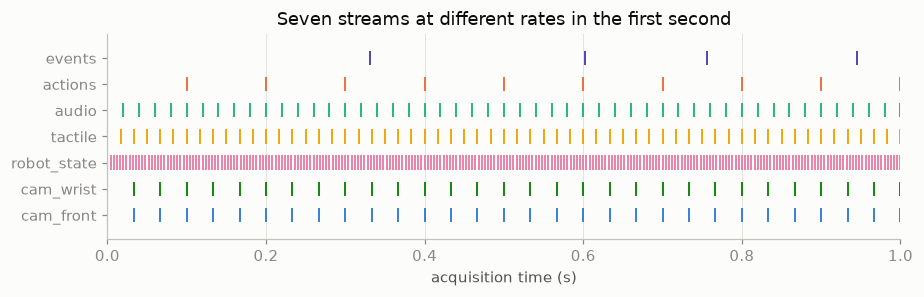

In [16]:
# First second of acquisition times. A policy frame has to combine samples
# from streams that update at different rates.
fig, ax = plt.subplots(figsize=(8.5, 2.8))
names = list(run)
for row, name in enumerate(names):
    t = [s.acquisition_time_ns / 1e9 for s in run[name] if s.acquisition_time_ns <= 1e9]
    ax.eventplot(t, lineoffsets=row, linelengths=0.55, linewidths=1.2,
                 colors=STREAM_COLORS[name])
ax.set_yticks(range(len(names)), names)
ax.set_xlim(0, 1.0)
ax.set_xlabel("acquisition time (s)")
ax.set_title("Seven streams at different rates in the first second")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 2. Add known timing problems

The profile at `configs/corrupt_kitchen_sink.yaml` is an all-corruptions demo.
It applies each v0 timing problem to a specific stream, with randomness coming
from one profile seed:

| stream | corruption |
|---|---|
| `cam_front` | gaussian jitter, sigma = 5 ms, plus 8 percent dropped frames |
| `cam_wrist` | +15 ms fixed latency plus two 20 ms burst stalls |
| `robot_state` | 50 ppm clock drift plus an 80 ms missing interval |
| `tactile` | 5 percent duplicate samples |
| `audio` | two non-monotonic receive-time swaps |

`apply_profile` returns the corrupted run and a sidecar listing exactly which
samples were removed. A real dataset will not have that sidecar, but it is
useful in a test fixture because we can check whether the aligner reports the
missing data we already know about.

In [17]:
profile = load_profile(REPO / "configs" / "corrupt_kitchen_sink.yaml")
result = apply_profile(run, profile)
bad = result.run

print("known removals in this generated fixture:")
for name, dropped in result.dropped.items():
    print(f"  {name}: {len(dropped)} samples removed")

known removals in this generated fixture:
  cam_front: 13 samples removed
  robot_state: 20 samples removed


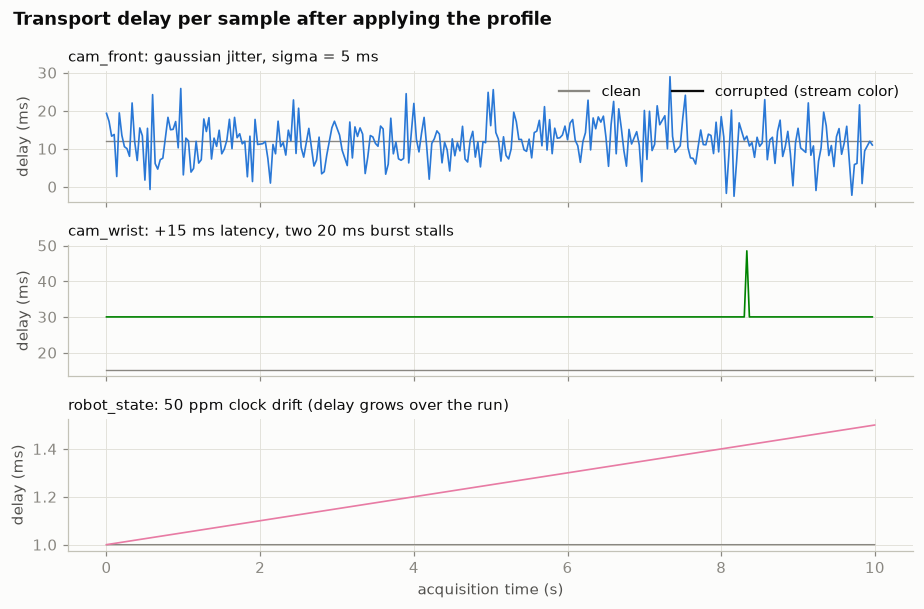

In [5]:
# Transport delay is receive time minus acquisition time. It shows timing
# problems that acquisition timestamps alone cannot show.
panels = [
    ("cam_front", "gaussian jitter, sigma = 5 ms"),
    ("cam_wrist", "+15 ms latency, two 20 ms burst stalls"),
    ("robot_state", "50 ppm clock drift (delay grows over the run)"),
]
fig, axes = plt.subplots(3, 1, figsize=(8.5, 5.6), sharex=True)
for ax, (name, subtitle) in zip(axes, panels):
    for samples, color, lw in ((run[name], MUTED, 0.9), (bad[name], STREAM_COLORS[name], 1.1)):
        t = [s.acquisition_time_ns / 1e9 for s in samples]
        d = [(s.receive_time_ns - s.acquisition_time_ns) / MS for s in samples]
        ax.plot(t, d, color=color, linewidth=lw)
    ax.set_title(f"{name}: {subtitle}", loc="left", fontsize=10)
    ax.set_ylabel("delay (ms)")
axes[0].plot([], [], color=MUTED, label="clean")
axes[0].plot([], [], color=INK, label="corrupted (stream color)")
axes[0].legend(loc="upper right", ncols=2)
axes[-1].set_xlabel("acquisition time (s)")
fig.suptitle("Transport delay per sample after applying the profile", x=0.02,
             ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Align into frames for a policy

`align_run` maps the corrupted run onto a fixed-rate target grid. The example
uses two choices that are worth calling out:

- The target rate is 12 Hz. It does not divide evenly into the stream rates,
  so the example shows nonzero skew instead of a perfectly lined-up toy case.
- The `events` stream is left out. It is sparse and irregular, so it would make
  most fixed-rate frames look missing. In practice, event markers are usually
  handled separately from dense observations.

Each frame carries metadata for each stream: which source sample was picked,
its signed skew, the alignment method, a missing flag, and a confidence score.
The confidence is based on skew compared with the stream tolerance, which is
half the median interval between samples.

In [18]:
dense = {name: samples for name, samples in bad.items() if name != "events"}
aligned = align_run(dense, target_rate_hz=12.0, method="nearest_neighbor",
                    ground_truth=result.dropped)
rep = aligned.report

print(f"frames: {len(aligned.frames)}")
print(f"{'stream':<12} {'missing':>8} {'median skew (ms)':>18}")
for name in dense:
    skew = rep.median_skew_ns[name]
    print(f"{name:<12} {rep.missing_count[name]:>8} "
          f"{'-' if skew is None else f'{skew / MS:+.3f}':>18}")

frame = aligned.frames[40]
print(f"\nframe @ t = {frame.target_time_ns / 1e9:.1f} s:")
for name, md_ in frame.metadata.items():
    skew = "-" if md_.skew_ns is None else f"{md_.skew_ns / MS:+7.2f} ms"
    print(f"  {name:<12} missing={str(md_.missing):<6} skew={skew:<12} "
          f"confidence={md_.confidence:.2f}")

frames: 119
stream        missing   median skew (ms)
cam_front           6             +0.000
cam_wrist           0             +0.000
robot_state         1             +0.000
tactile             0             +0.000
audio               0             -3.333
actions             0             +0.000

frame @ t = 3.3 s:
  cam_front    missing=False  skew=  +0.00 ms   confidence=1.00
  cam_wrist    missing=False  skew=  +0.00 ms   confidence=1.00
  robot_state  missing=False  skew=  -1.33 ms   confidence=0.33
  tactile      missing=False  skew=  +0.00 ms   confidence=1.00
  audio        missing=False  skew=  +6.67 ms   confidence=0.33
  actions      missing=False  skew= -33.33 ms   confidence=0.33


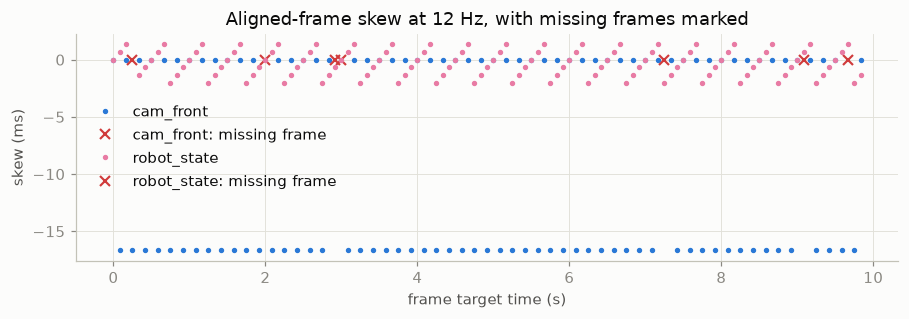

In [19]:
# Per-frame skew for the two streams whose acquisition timeline was changed.
# Dropped frames and missing intervals show up as missing flags.
fig, ax = plt.subplots(figsize=(8.5, 3.0))
for name in ("cam_front", "robot_state"):
    t, skew, miss_t = [], [], []
    for f in aligned.frames:
        m = f.metadata[name]
        if m.missing:
            miss_t.append(f.target_time_ns / 1e9)
        elif m.skew_ns is not None:
            t.append(f.target_time_ns / 1e9)
            skew.append(m.skew_ns / MS)
    ax.plot(t, skew, ".", markersize=5, color=STREAM_COLORS[name], label=name)
    if miss_t:
        ax.plot(miss_t, [0] * len(miss_t), "x", markersize=7, color=CRITICAL,
                markeredgewidth=1.4,
                label=f"{name}: missing frame" )
ax.set_xlabel("frame target time (s)")
ax.set_ylabel("skew (ms)")
ax.set_title("Aligned-frame skew at 12 Hz, with missing frames marked")
ax.legend(loc="center left", ncols=1)
plt.tight_layout()
plt.show()

The signed median skew tells you which way the alignment tends to lean. This
matters when training and deployment use different policies. Zero-order hold
only looks backward in time, while nearest-neighbor can pick a sample before or
after the target. Switching between them can shift a stream by part of a sample
period even when both policies are working as designed.

In [8]:
zoh = align_run(dense, target_rate_hz=12.0, method="zoh")
print(f"{'stream':<12} {'NN median skew (ms)':>20} {'ZoH median skew (ms)':>22}")
for name in dense:
    nn_s, zoh_s = aligned.report.median_skew_ns[name], zoh.report.median_skew_ns[name]
    def fmt(v):
        return "-" if v is None else f"{v / MS:+.3f}"
    print(f"{name:<12} {fmt(nn_s):>20} {fmt(zoh_s):>22}")

stream        NN median skew (ms)   ZoH median skew (ms)
cam_front                  +0.000                -16.667
cam_wrist                  +0.000                -16.667
robot_state                +0.000                 -1.333
tactile                    +0.000                 +0.000
audio                      -3.333                 -6.667
actions                    +0.000                -33.333


## 4. Build a sync-quality report

`build_report` turns an aligned episode into per-stream statistics. The CLI
command `embsync report`, or the Python helper `save_report_html`, writes the
same information as a self-contained HTML file you can keep with a dataset.
Because this example generated the removals, we can compare missing frames
reported by the aligner with samples the profile actually removed.

In [20]:
report = build_report(aligned)
print(f"{'stream':<12} {'missing%':>9} {'med |skew| ms':>14} {'med conf':>9} {'gt removed':>11}")
for s in report.streams:
    mskew = "-" if s.median_abs_skew_ns is None else f"{s.median_abs_skew_ns / MS:.3f}"
    mconf = "-" if s.median_confidence is None else f"{s.median_confidence:.2f}"
    print(f"{s.name:<12} {100 * s.missing_rate:>8.1f}% {mskew:>14} {mconf:>9} "
          f"{s.ground_truth_missing_count:>11}")

out = Path("output")
out.mkdir(exist_ok=True)
html_path = save_report_html(aligned, out / "sync_report.html",
                             title="All-corruptions demo", target_rate_hz=12.0)
print(f"\nself-contained HTML report -> {html_path}")

stream        missing%  med |skew| ms  med conf  gt removed
cam_front         5.0%          0.000      1.00          12
cam_wrist         0.0%          0.000      1.00           0
robot_state       0.8%          1.000      0.50          20
tactile           0.0%          0.000      1.00           0
audio             0.0%          6.667      0.33           0
actions           0.0%         33.333      0.33           0

self-contained HTML report -> output/sync_report.html


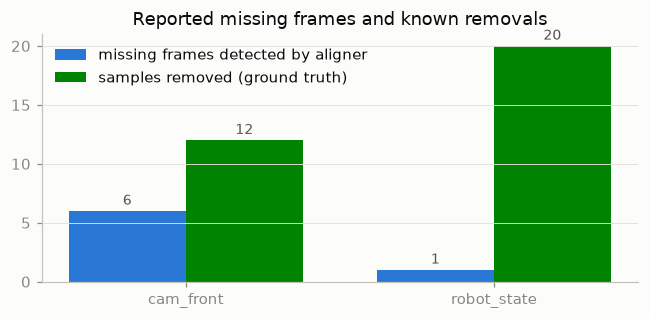

In [21]:
# Compare reported missing frames with known removals for streams where samples
# were actually removed.
streams = ["cam_front", "robot_state"]
detected = [aligned.report.missing_count[s] for s in streams]
known = [aligned.report.ground_truth_missing_count.get(s, 0) for s in streams]
x = range(len(streams))
w = 0.38
fig, ax = plt.subplots(figsize=(6.0, 3.0))
b1 = ax.bar([i - w / 2 for i in x], detected, w, color="#2a78d6",
            label="missing frames detected by aligner")
b2 = ax.bar([i + w / 2 for i in x], known, w, color="#008300",
            label="samples removed (ground truth)")
for bars in (b1, b2):
    ax.bar_label(bars, padding=2, color=INK2, fontsize=9)
ax.set_xticks(list(x), streams)
ax.grid(axis="x", visible=False)
ax.set_title("Reported missing frames and known removals")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The two bars use different units on purpose. Removed samples are not the same
as missing policy frames. For example, `robot_state` loses 20 samples in an
80 ms gap, but on a 12 Hz frame grid that usually becomes only one missing
frame. `cam_front` drops are scattered, so many fall between target frames. The
report helps separate data loss from what the policy frame builder actually
sees.

## 5. Use online alignment for a running policy

Offline alignment can look at the whole episode, but a running policy has to
work with samples that have already arrived. At tick time `now`, a sample that
was acquired in time but delivered late is not available yet.
`MultiStreamAligner` models that rule: push samples in receive
order, ask for a frame at each policy tick, and only samples with
`receive_time <= now` can be used. This is where latency, stalls, and drift
matter for the live observation.

In [11]:
tol = {"cam_front": 50 * MS, "cam_wrist": 50 * MS, "robot_state": 8 * MS}
online = MultiStreamAligner({n: StreamRingBuffer(capacity=512, tolerance_ns=t)
                             for n, t in tol.items()})
inbox = sorted((s for n in tol for s in bad[n]), key=lambda s: s.receive_time_ns)

i, staleness = 0, {n: [] for n in tol}
# About 10 Hz policy ticks, not phase-locked to any sensor. A policy loop clock
# usually does not line up with camera frame boundaries.
ticks = range(500_000_000, 9_500_000_001, 97_000_000)
for now in ticks:
    while i < len(inbox) and inbox[i].receive_time_ns <= now:
        online.push(inbox[i])
        i += 1
    f = online.get_latest_policy_frame(now)
    for n in tol:
        m = f.metadata[n]
        staleness[n].append(None if m.missing or m.source_time_ns is None
                            else (now - m.source_time_ns) / MS)

print(f"{'stream':<12} {'offline missing':>16} {'online missing':>15}")
for n in tol:
    off = sum(1 for f in aligned.frames if f.metadata[n].missing)
    on = sum(1 for v in staleness[n] if v is None)
    print(f"{n:<12} {off:>16} {on:>15}")

stream        offline missing  online missing
cam_front                   6               8
cam_wrist                   0              37
robot_state                 1               0


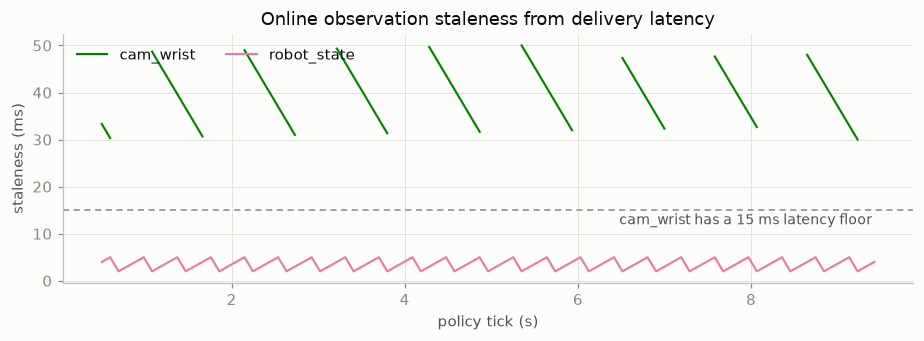

In [22]:
# Observation staleness per policy tick: how old is the newest usable sample?
fig, ax = plt.subplots(figsize=(8.5, 3.2))
t = [n / 1e9 for n in ticks]
for name in ("cam_wrist", "robot_state"):
    ax.plot(t, staleness[name], color=STREAM_COLORS[name], linewidth=1.4, label=name)
ax.axhline(15, color=MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate("cam_wrist has a 15 ms latency floor", xy=(9.4, 15),
            xytext=(9.4, 12), ha="right", color=INK2, fontsize=9)
ax.set_xlabel("policy tick (s)")
ax.set_ylabel("staleness (ms)")
ax.set_title("Online observation staleness from delivery latency")
ax.legend(loc="upper left", ncols=2)
plt.tight_layout()
plt.show()

`cam_wrist` has a sawtooth pattern because the policy tick moves against the
30 Hz camera frame phase. It never reaches zero because the profile added a
15 ms delivery delay, and the stalls add larger steps. Offline alignment of
the same stream reported near-zero median skew because the acquisition
timestamps were unchanged. If training uses offline alignment and the robot
uses online alignment, this plot shows how old the live observation can be.

## 6. A real dataset: LeRobot

Everything above ran on a generated fixture. The same library reads real
LeRobot **v3.0** datasets too — the format Hugging Face's `lerobot` datasets
ship in as of this writing: `meta/info.json` for fps and feature dtypes,
`meta/tasks.parquet` for the task strings, `meta/episodes/*.parquet` for
per-episode row ranges, and chunked `data/*.parquet` files for the actual
rows. `load_lerobot_dataset` reads all of that and returns the same `Sample`
objects used everywhere else in this notebook, so corruption, alignment, and
reporting all apply unchanged.

A few things worth knowing about what the reader does:

- Stored timestamps are float32 seconds, per episode. They convert to
  integer nanoseconds with `round(ts * 1e9)` — including whatever float32
  rounding is already baked into the file. That is not cleaned up, because
  it is part of the dataset's real precision.
- Episodes are laid end to end on one timeline: episode 1 starts exactly
  where episode 0's frames end, on the dataset's frame grid.
- Video frames are not decoded. Each sample gets a `payload_ref` naming the
  video file, a seek time, and a frame index, so a viewer can pull the pixel
  data if it needs it.

This cell looks for one of the PushT checkouts under
`data/external/lerobot/` and prints what it finds. If you do not have that
directory, it prints a short message instead — see the CLI commands in the
next section for the same import from the command line.

In [23]:
# Real LeRobot v3.0 dataset import (needs pyarrow: `pip install -e ".[lerobot]"`).
from embodied_sync.adapters.lerobot import load_lerobot_dataset

LEROBOT_ROOT = REPO / "data" / "external" / "lerobot" / "pusht"
if not LEROBOT_ROOT.exists():
    print(f"no local dataset at {LEROBOT_ROOT} -- see the CLI commands in section 7 instead.")
else:
    try:
        lerobot_run, lerobot_info = load_lerobot_dataset(LEROBOT_ROOT, max_episodes=5)
    except ModuleNotFoundError:
        print("pyarrow is not installed -- install the 'lerobot' extra to run this cell.")
    else:
        print(f"dataset: {LEROBOT_ROOT.name}  (codebase {lerobot_info['codebase_version']}, "
              f"{lerobot_info['fps']:.0f} fps)")
        print(f"task: {next(iter(lerobot_info['tasks'].values()))}")
        print(f"imported {lerobot_info['imported_episodes']} of "
              f"{lerobot_info['total_episodes']} episodes\n")
        print(f"{'stream':<20} {'samples':>8}  first sample's payload / payload_ref")
        for name, samples in lerobot_run.items():
            s0 = samples[0]
            detail = s0.payload_ref if s0.payload_ref is not None else s0.payload
            print(f"{name:<20} {len(samples):>8}  {str(detail)[:56]}")

        ep0, ep1 = lerobot_info["episodes"][0], lerobot_info["episodes"][1]
        print(f"\nepisode 0: {ep0['length']} frames, starts at t=0")
        print(f"episode 1: starts at t={ep1['start_time_ns'] / 1e9:.3f} s, "
              f"right after episode 0 ends")

KeyboardInterrupt: 

The imported streams carry `receive_time_ns == acquisition_time_ns`.
LeRobot's format has no notion of delivery time — it only records when a
sample was captured — so there is nothing to set `receive_time_ns` to except
the same value. That is different from every stream earlier in this
notebook, where the synthetic generator gave each stream its own fixed
transport delay on purpose. If your own capture pipeline logs delivery
times separately, that is the gap a custom adapter would fill in.

## 7. Using it on your data

The CLI mirrors everything above, directory-in / directory-out. For a
synthetic run:

```bash
pip install -e ".[dev]"          # from a checkout; base dependencies are numpy + pyyaml
embsync synth   --out runs/clean --seed 0 --duration-s 10
embsync corrupt runs/clean --profile configs/corrupt_kitchen_sink.yaml --out runs/bad
embsync align   runs/bad --out episodes/bad_10hz --target-rate-hz 10 --check-ground-truth
embsync report  episodes/bad_10hz --out reports/bad.html --json-summary reports/bad.json
```

For a real LeRobot v3.0 dataset, the same shape applies. `import-lerobot`
takes the place of `synth`, and `--target-rate-hz` is optional on `align` and
`report` — it defaults to the dataset's own fps, recorded during import:

```bash
pip install -e ".[lerobot]"      # adds pyarrow
embsync import-lerobot data/external/lerobot/pusht --out runs/lerobot_pusht
embsync report runs/lerobot_pusht

embsync import-lerobot data/external/lerobot/pusht_image --out runs/lerobot_pusht_image
embsync align runs/lerobot_pusht_image --out episodes/lerobot_pusht_image_aligned
embsync export-lerobot episodes/lerobot_pusht_image_aligned --out out/lerobot_roundtrip
```

`export-lerobot` writes a minimal LeRobot v3.0 dataset back out. It only
covers numeric streams — no video transcoding — and frames a stream is
missing from export as `NaN` rather than inventing a value. The result reads
back through `import-lerobot` unchanged, so a training pipeline built on
LeRobot's own loader can consume it directly.

Two more things not shown above, both offline-adjacent:

- **`SyncSession`** is the *live* counterpart to everything in this
  notebook — wrap a vendor SDK's callbacks, `push`/`get()` a
  synchronized bundle, and record straight into the same run-directory
  format `generate_synthetic_run` writes above, so this notebook's
  alignment/report cells apply unchanged to a live capture. See the
  README quickstart and `embodied_sync/session/session.py`'s docstring.
- **`embodied_sync.calibrate`** recovers the offset/drift mapping
  between two real device clocks (from a shared clap, QR/screen
  timestamp, or matched event train) — `embsync calibrate clap` runs
  the audio path end to end. That mapping is what makes cross-device
  alignment honest instead of assumed.
- For a directory you don't already have an adapter for, skip writing
  one: `embsync inspect-dataset` / `infer-import` / `import-auto`
  profile the layout and propose an evidence-backed import plan instead
  of guessed code. See `docs/user/automatic_dataset_import.md`.

Current status: the run and episode format, corruption engine, offline and
online aligners, session, calibration estimator, and reports are
implemented and covered by deterministic tests. LeRobot v3.0 and
LabRecorder XDF now have real readers, not just CI contract fixtures —
the LeRobot cell above ran against an actual PushT checkout. MCAP and UMI
still cover contract paths only, plus a true-binary MCAP read path that
preserves rosbag2 publish and log timestamps. A native UMI-zarr reader is
still planned; sample files are useful here because they let it be tested
against files people actually use.

- Concepts: `docs/concepts/` (latency vs jitter vs drift, online vs offline alignment, timestamps and clock domains)
- Choosing a policy: `docs/user/choosing_alignment_policy.md`
- Reading reports: `docs/user/interpreting_sync_reports.md`
- Adapter authoring: `docs/developer/adapter_authoring_guide.md`
- Automatic import for unfamiliar layouts: `docs/user/automatic_dataset_import.md`